# Joint DFE High-r Production: Demography & DFE Inference Results

In [4]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats.distributions as ssd

BASE_DIR = "/Users/srgib/GitHub/dadi_polyploidy/thesis_figures/SLiM_DFE_results/joint_DFE"
DEMOG_DIR = os.path.join(BASE_DIR, "demography")
DFE_DIR = os.path.join(BASE_DIR, "DFE")

REP_RE = re.compile(r'REP_(\d+)')

# joint DFE: lognormal with sigma as the scipy shape parameter and scale=np.exp(mu),
# i.e. scipy.stats.distributions.lognorm(sigma, scale=np.exp(mu))
TRUE_MU = 1.69155136
TRUE_SIGMA = 2.37871223
TRUE_W = 0.075

method_colors = {
    'dadi_nomisid': "#1f77b4",
    'dadi_misid': "#ff7f0e",
}
method_labels = {
    'dadi_nomisid': 'dadi (no misid)',
    'dadi_misid': 'dadi (misid)',
}


def get_best_fit_params(opt_file):
    """
    Load the best-fit row (highest log-likelihood < 0) from a dadi
    optimization results file, keyed by that file's own header. Works for
    both demography and DFE optimization files, with or without a misid
    column, since the parameter names are read from the header rather
    than passed in.
    """
    with open(opt_file, 'r') as f:
        lines = f.readlines()
    param_names = lines[0].strip().split('\t')[1:]

    best_line, best_ll = None, float('-inf')
    for line in lines[1:]:
        parts = line.strip().split('\t')
        ll = float(parts[0])
        if (ll > best_ll) and (ll < 0):
            best_ll = ll
            best_line = parts

    return {name: float(best_line[i + 1]) for i, name in enumerate(param_names)}


def load_replicates(directory, file_prefix, parser):
    """Map REP number -> parsed parameter dict for every matching file in `directory`."""
    results = {}
    for path in glob.glob(os.path.join(directory, f"{file_prefix}*.txt")):
        rep = int(REP_RE.search(os.path.basename(path)).group(1))
        results[rep] = parser(path)
    return results


## Demographic parameter estimates

In [5]:
# four demographic inference configurations: {small, large} x {misid, no misid}
# (no medium size for Joint DFE)
demog_configs = {
    'small': 'bg_sc_small',
    'large': 'bg_sc_large',
    'small_misid': 'bg_sc_misid_small',
    'large_misid': 'bg_sc_misid_large',
}

demog_data = {
    label: load_replicates(os.path.join(DEMOG_DIR, folder), 'optimization_', get_best_fit_params)
    for label, folder in demog_configs.items()
}


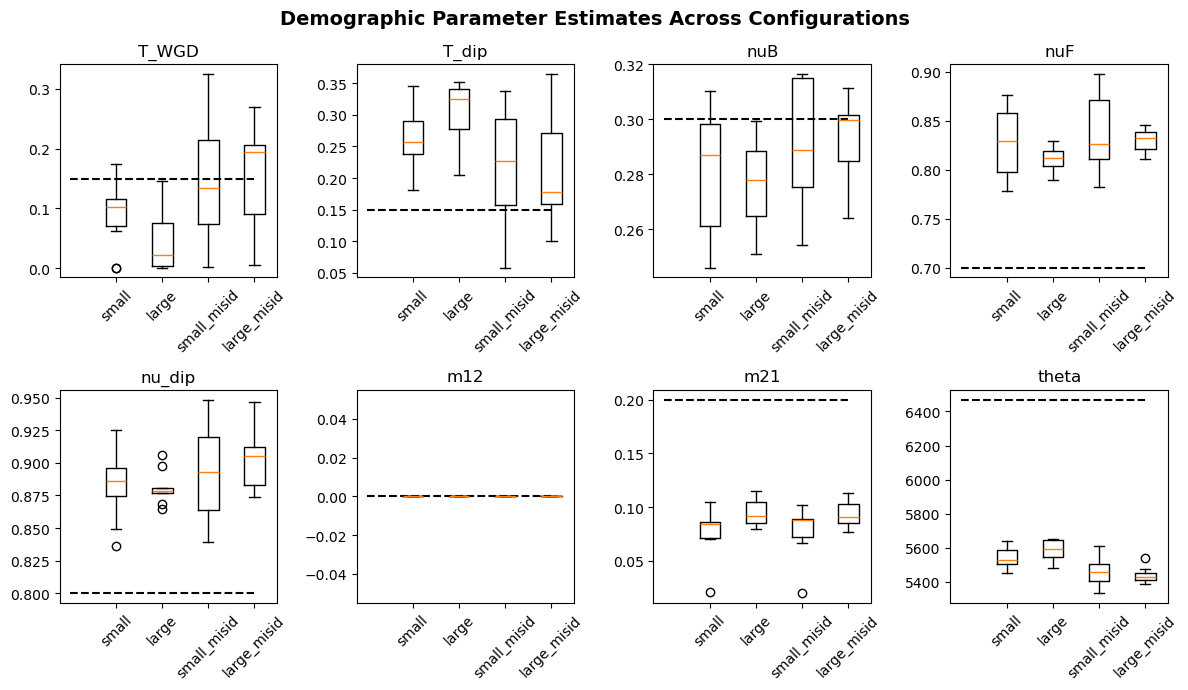

In [6]:
# T_WGD, T_dip, nuB, nuF, nu_dip, and theta are estimated in all four configs; misid only in the two *_misid configs
demog_params = ['T_WGD', 'T_dip', 'nuB', 'nuF', 'nu_dip', 'm12', 'm21', 'theta']

theta_true_syn = 161744 * 4 * 5e6 * 7e-9 * (1/3.5)
true_vals = [0.15, 0.15, 0.3, 0.7, 0.8, 0.0, 0.2, theta_true_syn]

fig, axes = plt.subplots(2, 4, figsize=(12, 7))
axes = axes.flatten()

for ax, param, true_val in zip(axes, demog_params, true_vals):
    labels = [label for label, reps in demog_data.items() if param in next(iter(reps.values()))]
    values = [[rep_params[param] for rep_params in demog_data[label].values()] for label in labels]
    ax.boxplot(values, tick_labels=labels)
    ax.set_title(param)
    ax.tick_params(axis='x', rotation=45)
    ax.hlines(true_val, xmin=0, xmax=len(labels), color='black', linestyle='dashed')

for ax in axes[len(demog_params):]:
    ax.axis('off')
fig.suptitle('Demographic Parameter Estimates Across Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'demography_boxplots.pdf'), bbox_inches='tight')
plt.show()

## DFE inference: location & scale

In [8]:
# for each size, the no-misid and misid runs live in separate folders, holding dadi's
# DFE_optimization_* results only -- fastDFE results aren't available here since fastDFE only
# supports inference from a single population, but this joint DFE spans two subgenomes
dfe_dirs = {
    'small': {'nomisid': 'bg_sc_small', 'misid': 'bg_sc_misid_small'},
    'large': {'nomisid': 'bg_sc_large', 'misid': 'bg_sc_misid_large'},
}

# dfe_data[size][tag] -> {rep: param_dict}, kept keyed by REP so with/without-misid
# fits can be paired up by the replicate they came from (see the pairwise section below)
dfe_data = {
    size: {
        tag: load_replicates(os.path.join(DFE_DIR, folder), 'DFE_optimization_', get_best_fit_params)
        for tag, folder in dirs.items()
    }
    for size, dirs in dfe_dirs.items()
}

dfe_methods = ['dadi_nomisid', 'dadi_misid']
dfe_tags = {'dadi_nomisid': 'nomisid', 'dadi_misid': 'misid'}

# dfe_shape_scale[size][method] -> list of (mu, sigma) pairs over the 10 replicates
# dfe_w[size][method] -> list of w values (weight on the subgenome-decorrelated 2d component) over the 10 replicates
dfe_shape_scale = {
    size: {method: [(p['mu'], p['sigma']) for p in dfe_data[size][dfe_tags[method]].values()]
           for method in dfe_methods}
    for size in dfe_data
}
dfe_w = {
    size: {method: [p['w'] for p in dfe_data[size][dfe_tags[method]].values()]
           for method in dfe_methods}
    for size in dfe_data
}

# small/large x nomisid/misid -> four groups, each with its own color
group_order = [(size, method) for size in ('small', 'large') for method in dfe_methods]
group_colors = {
    ('small', 'dadi_nomisid'): '#1f77b4',
    ('small', 'dadi_misid'): '#aec7e8',
    ('large', 'dadi_nomisid'): '#ff7f0e',
    ('large', 'dadi_misid'): '#ffbb78',
}
group_labels = {
    ('small', 'dadi_nomisid'): 'small, no misid',
    ('small', 'dadi_misid'): 'small, misid',
    ('large', 'dadi_nomisid'): 'large, no misid',
    ('large', 'dadi_misid'): 'large, misid',
}

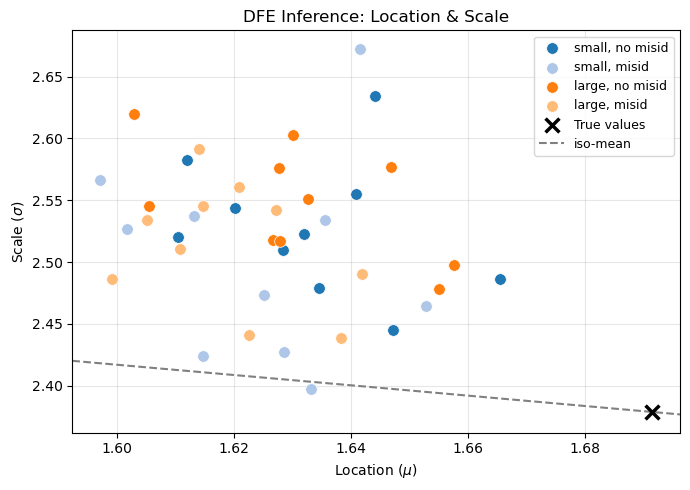

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
for size, method in group_order:
    mus, sigmas = zip(*dfe_shape_scale[size][method])
    ax.scatter(mus, sigmas, label=group_labels[(size, method)], color=group_colors[(size, method)],
               s=70, edgecolors='white', linewidths=0.5, zorder=3)

ax.scatter(TRUE_MU, TRUE_SIGMA, marker='x', color='black', s=100, linewidths=2.5,
           zorder=5, label='True values')

# iso-mean contour: exp(mu + sigma^2/2) = true mean, the constant-mean curve passing through the true point
xlim = ax.get_xlim()
true_mean = np.exp(TRUE_MU + TRUE_SIGMA**2 / 2)
mu_range = np.linspace(*xlim, 200)
with np.errstate(invalid='ignore'):
    sigma_curve = np.sqrt(2 * (np.log(true_mean) - mu_range))
ax.plot(mu_range, sigma_curve, linestyle='--', color='gray', linewidth=1.5,
        zorder=2, label='iso-mean')

# true_var = (np.exp(TRUE_SIGMA**2) - 1) * np.exp(2*TRUE_MU + TRUE_SIGMA**2)
# var_range = np.linspace(*xlim, 200)
# with np.errstate(invalid='ignore'):
#     var_curve = np.sqrt(np.log((1 + np.sqrt(1 + 4*true_var*np.exp(-2*mu_range))/2)))
# ax.plot(mu_range, var_curve, linestyle='-.', color='black', linewidth=1.5,
#         zorder=2, label='iso-variance')

ax.set_xlim(xlim)

ax.set_xlabel(r'Location ($\mu$)')
ax.set_ylabel(r'Scale ($\sigma$)')
ax.set_title('DFE Inference: Location & Scale')
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_scatter_combined.pdf'), bbox_inches='tight')
plt.show()

## DFE inference: mixture weight (w)

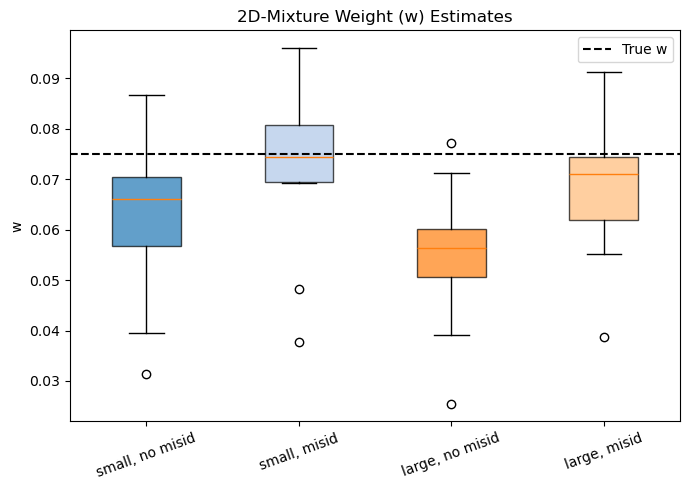

In [10]:
w_labels = [group_labels[key] for key in group_order]
w_values = [dfe_w[size][method] for size, method in group_order]
w_colors = [group_colors[key] for key in group_order]

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(w_values, tick_labels=w_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], w_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.hlines(TRUE_W, xmin=0.5, xmax=len(w_labels) + 0.5, color='black', linestyle='dashed', label='True w')
ax.set_title('2D-Mixture Weight (w) Estimates')
ax.set_ylabel('w')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_w_boxplot.pdf'), bbox_inches='tight')
plt.show()

## DFE inference: with vs without misid

In [11]:
def plot_param_scatter(ax, xdict, ydict, param, true_val=None, title=None,
                        xlabel='No misid', ylabel='Misid'):
    '''
    Paired per-replicate scatter of a DFE parameter estimated without (x) vs with (y)
    ancestral-state misidentification, matched by REP so the same simulated replicate
    lines up on both axes.
    '''
    reps = sorted(set(xdict) & set(ydict))
    x = np.array([xdict[r][param] for r in reps])
    y = np.array([ydict[r][param] for r in reps])

    ax.scatter(x, y, alpha=0.7, color='steelblue', s=60, edgecolors='white', linewidths=0.5, zorder=3)

    vals = list(x) + list(y) + ([true_val] if true_val is not None else [])
    lo, hi = min(vals), max(vals)
    pad = (hi - lo) * 0.08 or 1
    lo, hi = lo - pad, hi + pad
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, linewidth=1, zorder=2)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    if true_val is not None:
        ax.axvline(true_val, color='gray', linestyle='--', alpha=0.5, zorder=1)
        ax.axhline(true_val, color='gray', linestyle='--', alpha=0.5, zorder=1)
        ax.plot(true_val, true_val, 'ko', markersize=8, zorder=4)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)


dfe_pairwise_params = [
    ('mu', TRUE_MU, 'Location (μ)'),
    ('sigma', TRUE_SIGMA, 'Scale (σ)'),
    ('w', TRUE_W, 'Mixture weight (w)'),
]

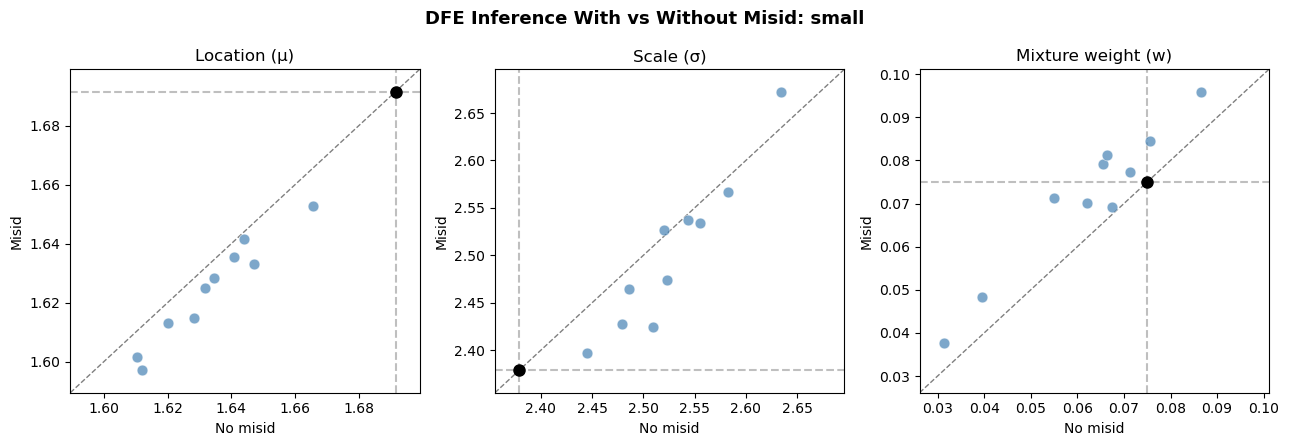

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (param, true_val, title) in zip(axes, dfe_pairwise_params):
    plot_param_scatter(ax, dfe_data['small']['nomisid'], dfe_data['small']['misid'],
                        param, true_val=true_val, title=title)
fig.suptitle('DFE Inference With vs Without Misid: small', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_pairwise_misid_small.pdf'), bbox_inches='tight')
plt.show()

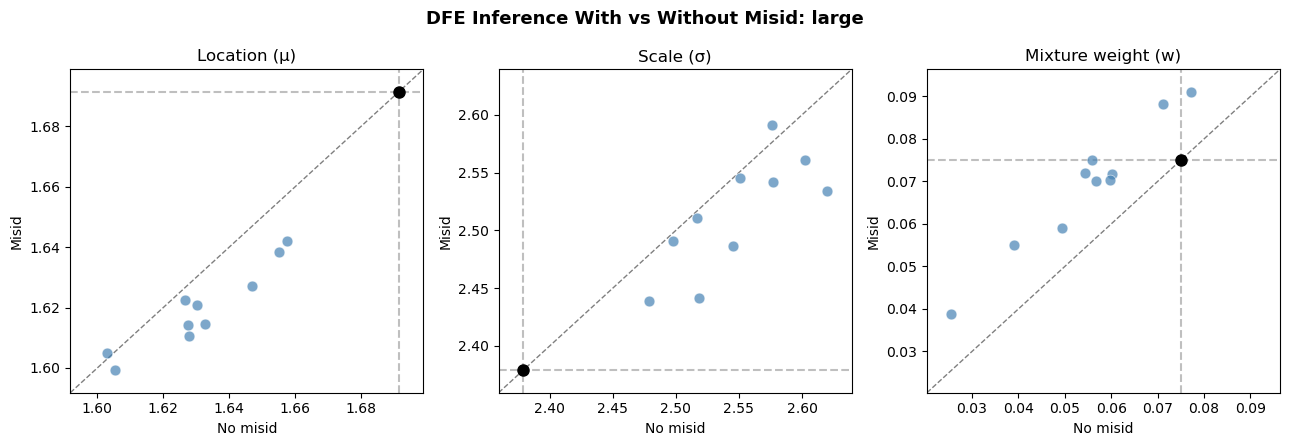

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (param, true_val, title) in zip(axes, dfe_pairwise_params):
    plot_param_scatter(ax, dfe_data['large']['nomisid'], dfe_data['large']['misid'],
                        param, true_val=true_val, title=title)
fig.suptitle('DFE Inference With vs Without Misid: large', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_pairwise_misid_large.pdf'), bbox_inches='tight')
plt.show()

## Discretized DFE

In [14]:
bin_labels = ("gamma<2", "2<gamma<20", "20<gamma<200", "gamma>200")


def discretized_bins(mu, sigma):
    '''Proportion of a lognormal(mu, sigma) distribution falling in each of the four 2Ns bins.'''
    c1 = ssd.lognorm.cdf(2, sigma, scale=np.exp(mu))
    c10 = ssd.lognorm.cdf(20, sigma, scale=np.exp(mu))
    c100 = ssd.lognorm.cdf(200, sigma, scale=np.exp(mu))
    return [c1, c10 - c1, c100 - c10, 1 - c100]


def average_bins(mu_sigma_pairs):
    '''
    Average the discretized bins across replicates rather than averaging
    mu/sigma first, since the mean of several lognormal distributions'
    parameters does not itself define a lognormal distribution.
    '''
    bins = np.array([discretized_bins(mu, sigma) for mu, sigma in mu_sigma_pairs])
    return bins.mean(axis=0)


true_bins = discretized_bins(TRUE_MU, TRUE_SIGMA)

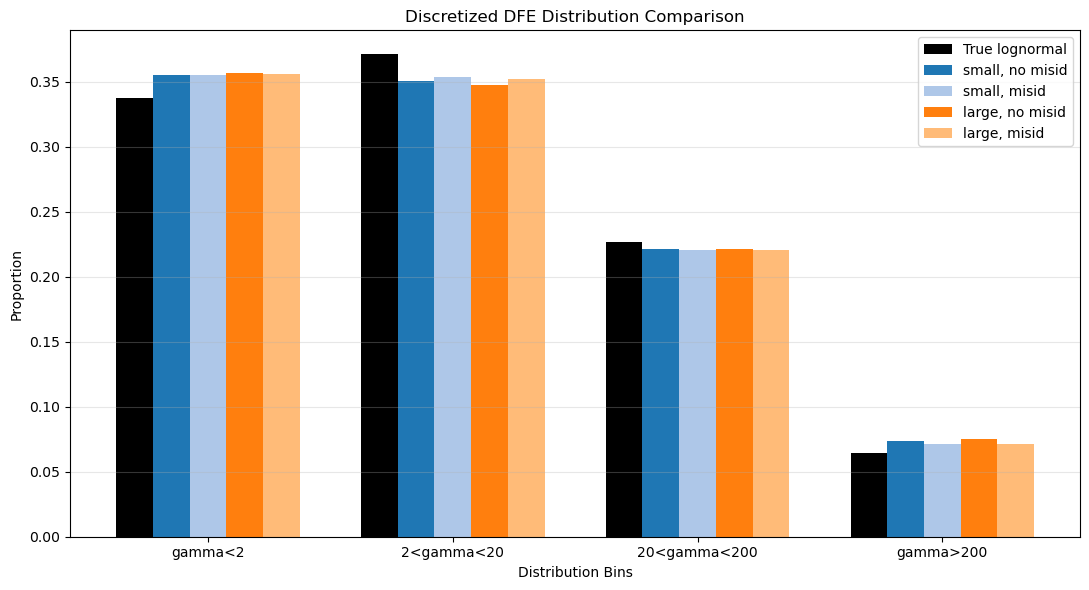

In [15]:
groups = ['true'] + group_order
bin_vals = {'true': true_bins}
bar_colors = {'true': '#000000'}
bar_labels = {'true': 'True lognormal'}
for size, method in group_order:
    bin_vals[(size, method)] = average_bins(dfe_shape_scale[size][method])
    bar_colors[(size, method)] = group_colors[(size, method)]
    bar_labels[(size, method)] = group_labels[(size, method)]

fig, ax = plt.subplots(figsize=(11, 6))
n_bins = len(bin_labels)
n_groups = len(groups)
bar_width = 0.15
bin_positions = np.arange(n_bins)

for i, group in enumerate(groups):
    offset = (i - (n_groups - 1) / 2) * bar_width
    ax.bar(bin_positions + offset, bin_vals[group], bar_width,
           label=bar_labels[group], color=bar_colors[group])

ax.set_xlabel('Distribution Bins')
ax.set_ylabel('Proportion')
ax.set_title('Discretized DFE Distribution Comparison')
ax.set_xticks(bin_positions)
ax.set_xticklabels(bin_labels)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_discretized_combined.pdf'), bbox_inches='tight')
plt.show()